In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [3]:
# Loading the train set
train = pd.read_csv('Datast/train.csv')
building = pd.read_csv('Datast/building_metadata.csv')
weather_train = pd.read_csv('Datast/weather_train.csv')


In [5]:
# Loading test set
test_data = pd.read_csv('Datast/test.csv') 
weather_test_data = pd.read_csv('Datast/weather_test.csv') 

In [6]:
train_df = train.merge(building, on='building_id', how='inner')
train_df = train_df.merge(weather_train, on=['site_id', 'timestamp'], how='inner')

In [7]:
test_df = test_data.merge(building, on='building_id', how='inner')
test_df = test_df.merge(weather_test_data, on=['site_id', 'timestamp'], how='inner')

In [8]:
train_df.loc[(train_df['site_id'] == 0) & (train_df['meter'] == 0), 'meter_reading'] = train_df[(train_df['site_id'] == 0) & (train_df['meter'] == 0)]['meter_reading'] * 0.2931

In [9]:
train_df['timestamp']= pd.to_datetime(train_df['timestamp'])
train_df['hour']= np.uint8(train_df['timestamp'].dt.hour)
train_df['dayofweek']= np.uint8(train_df['timestamp'].dt.dayofweek)
train_df['month']= np.uint8(train_df['timestamp'].dt.month)
train_df['dayofyear']= np.uint16(train_df['timestamp'].dt.dayofyear)
train_df['day']= np.uint16(train_df['timestamp'].dt.day) #day of month
train_df['year']= np.uint16(train_df['timestamp'].dt.year)

In [10]:
test_df['timestamp']= pd.to_datetime(test_df['timestamp'])
test_df['hour']= np.uint8(test_df['timestamp'].dt.hour)
test_df['dayofweek']= np.uint8(test_df['timestamp'].dt.dayofweek)
test_df['month']= np.uint8(test_df['timestamp'].dt.month)
test_df['dayofyear']= np.uint16(test_df['timestamp'].dt.dayofyear)
test_df['day']= np.uint16(test_df['timestamp'].dt.day) #day of month
test_df['year']= np.uint16(test_df['timestamp'].dt.year)

In [11]:
train_df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,hour,dayofweek,month,dayofyear,day,year
0,0,0,2016-01-01,0.0,0,Education,7432,2008.0,NaN,25.0,...,NaN,1019.7,0.0,0.0,0,4,1,1,1,2016
1,1,0,2016-01-01,0.0,0,Education,2720,2004.0,NaN,25.0,...,NaN,1019.7,0.0,0.0,0,4,1,1,1,2016
2,2,0,2016-01-01,0.0,0,Education,5376,1991.0,NaN,25.0,...,NaN,1019.7,0.0,0.0,0,4,1,1,1,2016
3,3,0,2016-01-01,0.0,0,Education,23685,2002.0,NaN,25.0,...,NaN,1019.7,0.0,0.0,0,4,1,1,1,2016
4,4,0,2016-01-01,0.0,0,Education,116607,1975.0,NaN,25.0,...,NaN,1019.7,0.0,0.0,0,4,1,1,1,2016


In [23]:
train_df.describe()

,building_id,meter,timestamp,meter_reading,site_id,square_feet,year_built,floor_count,air_temperature,cloud_coverage,...,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,hour,dayofweek,month,dayofyear,day,year
count,2.012560e+07,2.012560e+07,20125605,2.012560e+07,2.012560e+07,2.012560e+07,8.012299e+06,3.495553e+06,2.011944e+07,1.139074e+07,...,1.646708e+07,1.898443e+07,1.876705e+07,2.007242e+07,2.012560e+07,2.012560e+07,2.012560e+07,2.012560e+07,2.012560e+07,20125605.0
mean,7.972116e+02,6.617305e-01,2016-07-04 03:13:39.759843328,2.117585e+03,7.967773e+00,1.077848e+05,1.968346e+03,4.175366e+00,1.598795e+01,1.900423e+00,...,7.964155e-01,1.016085e+03,1.730151e+02,3.377525e+00,1.151151e+01,3.007445e+00,6.583859e+00,1.856548e+02,1.577263e+01,2016.0
min,0.000000e+00,0.000000e+00,2016-01-01 00:00:00,0.000000e+00,0.000000e+00,2.830000e+02,1.900000e+03,1.000000e+00,-2.890000e+01,0.000000e+00,...,-1.000000e+00,9.682000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2016.0
25%,3.910000e+02,0.000000e+00,2016-04-06 01:00:00,1.798000e+01,3.000000e+00,3.252700e+04,1.951000e+03,1.000000e+00,8.600000e+00,0.000000e+00,...,0.000000e+00,1.011600e+03,7.000000e+01,2.100000e+00,6.000000e+00,1.000000e+00,4.000000e+00,9.700000e+01,8.000000e+00,2016.0
50%,8.940000e+02,0.000000e+00,2016-07-04 22:00:00,7.503250e+01,9.000000e+00,7.270900e+04,1.970000e+03,3.000000e+00,1.670000e+01,0.000000e+00,...,0.000000e+00,1.016000e+03,1.800000e+02,3.100000e+00,1.200000e+01,3.000000e+00,7.000000e+00,1.860000e+02,1.600000e+01,2016.0
75%,1.176000e+03,1.000000e+00,2016-10-03 03:00:00,2.523490e+02,1.300000e+01,1.391130e+05,1.993000e+03,6.000000e+00,2.410000e+01,4.000000e+00,...,0.000000e+00,1.020500e+03,2.800000e+02,4.600000e+00,1.800000e+01,5.000000e+00,1.000000e+01,2.770000e+02,2.300000e+01,2016.0
max,1.448000e+03,3.000000e+00,2016-12-31 23:00:00,2.190470e+07,1.500000e+01,8.750000e+05,2.017000e+03,2.600000e+01,4.720000e+01,9.000000e+00,...,3.430000e+02,1.045500e+03,3.600000e+02,1.900000e+01,2.300000e+01,6.000000e+00,1.200000e+01,3.660000e+02,3.100000e+01,2016.0
std,4.263729e+02,9.310748e-01,NaN,1.535797e+05,5.092223e+00,1.171616e+05,3.020659e+01,3.992855e+00,1.094729e+01,2.402909e+00,...,7.468997e+00,7.060539e+00,1.140574e+02,2.265694e+00,6.923813e+00,1.996799e+00,3.435704e+00,1.052207e+02,8.819310e+00,0.0


In [25]:
train_df.isnull().sum()

building_id                  0
meter                        0
timestamp                    0
meter_reading                0
site_id                      0
primary_use                  0
square_feet                  0
year_built            12113306
floor_count           16630052
air_temperature           6163
cloud_coverage         8734870
dew_temperature           9645
precip_depth_1_hr      3658528
sea_level_pressure     1141174
wind_direction         1358553
wind_speed               53181
hour                         0
dayofweek                    0
month                        0
dayofyear                    0
day                          0
year                         0
dtype: int64

In [27]:
test_df.isnull().sum()

row_id                       0
building_id                  0
meter                        0
timestamp                    0
site_id                      0
primary_use                  0
square_feet                  0
year_built            24545609
floor_count           34329308
air_temperature          22872
cloud_coverage        19343151
dew_temperature          61770
precip_depth_1_hr      7602534
sea_level_pressure     2317797
wind_direction         2779634
wind_speed              103060
hour                         0
dayofweek                    0
month                        0
dayofyear                    0
day                          0
year                         0
dtype: int64

In [35]:
train_df[train_df.duplicated()].value_counts()

Series([], Name: count, dtype: int64)

array([[<Axes: title={'center': 'building_id'}>,
        <Axes: title={'center': 'meter'}>,
        <Axes: title={'center': 'timestamp'}>,
        <Axes: title={'center': 'meter_reading'}>,
        <Axes: title={'center': 'site_id'}>],
       [<Axes: title={'center': 'square_feet'}>,
        <Axes: title={'center': 'year_built'}>,
        <Axes: title={'center': 'floor_count'}>,
        <Axes: title={'center': 'air_temperature'}>,
        <Axes: title={'center': 'cloud_coverage'}>],
       [<Axes: title={'center': 'dew_temperature'}>,
        <Axes: title={'center': 'precip_depth_1_hr'}>,
        <Axes: title={'center': 'sea_level_pressure'}>,
        <Axes: title={'center': 'wind_direction'}>,
        <Axes: title={'center': 'wind_speed'}>],
       [<Axes: title={'center': 'hour'}>,
        <Axes: title={'center': 'dayofweek'}>,
        <Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'dayofyear'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'cen

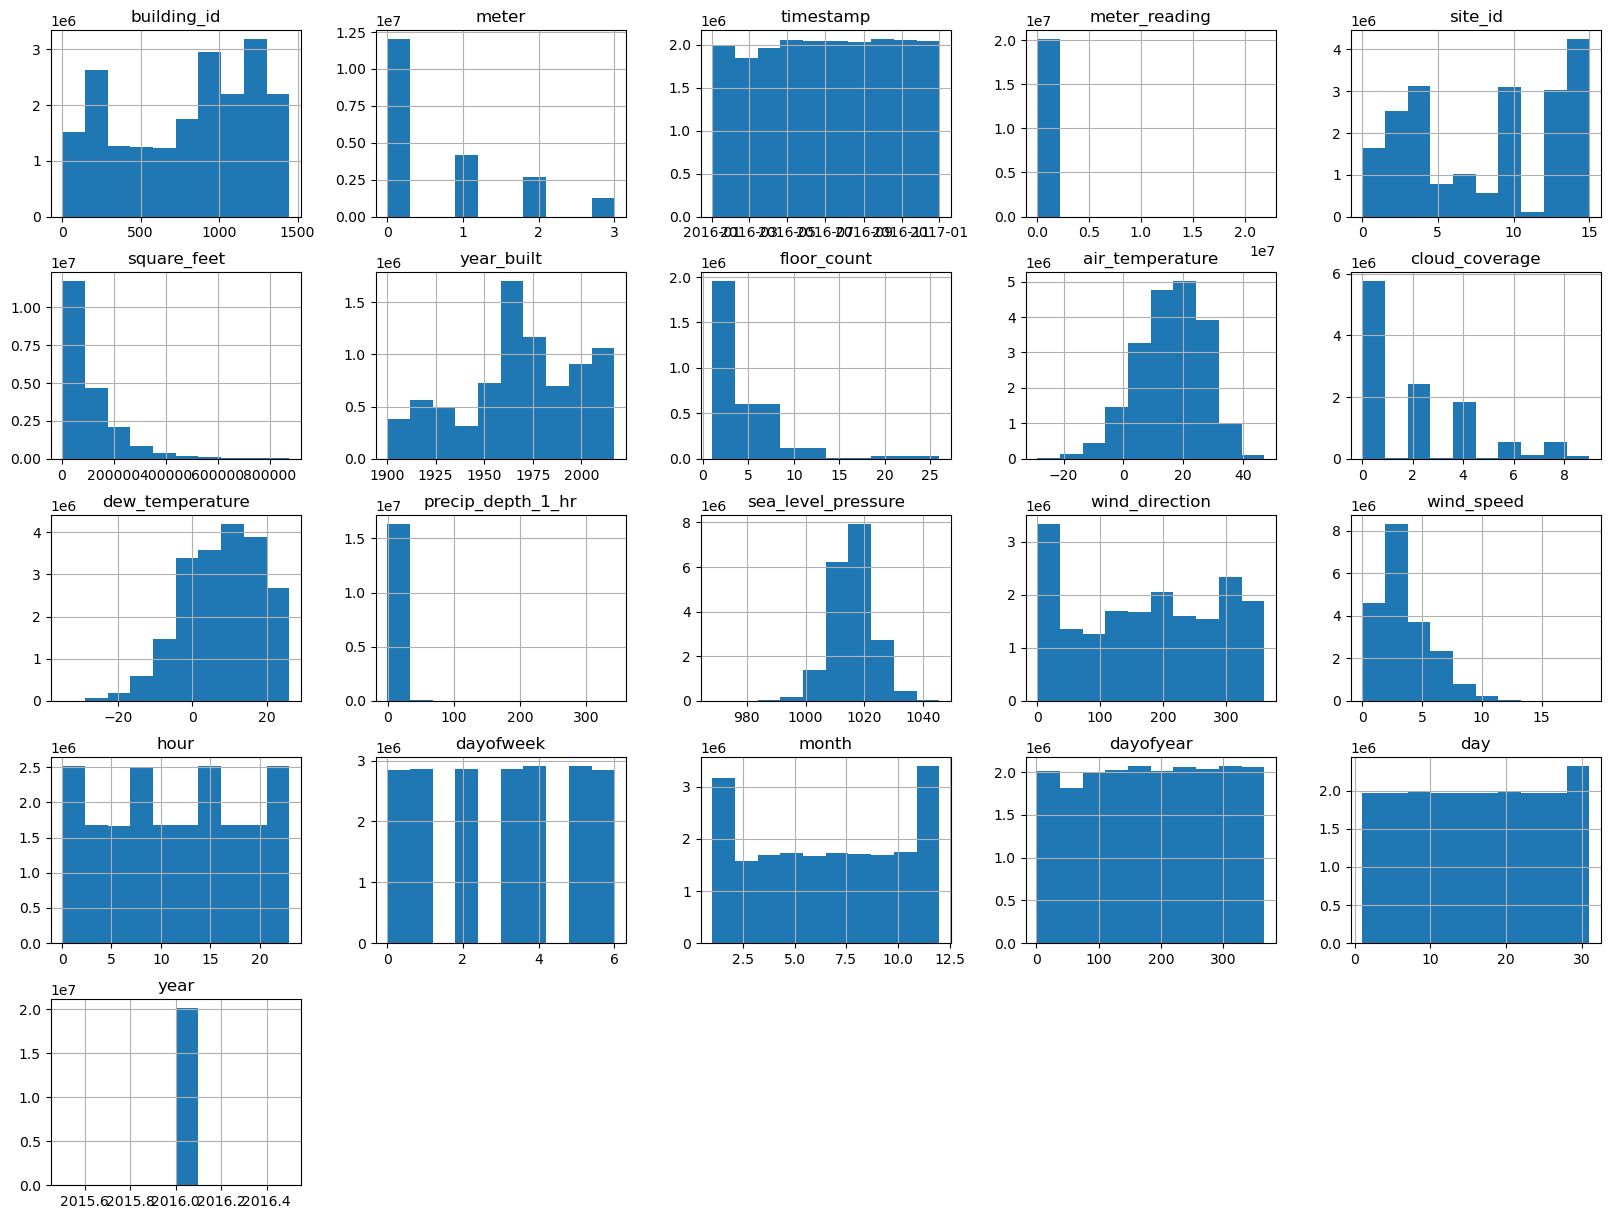

In [37]:
train_df.hist(figsize=(20,15))

In [39]:
train_df['meter_reading_log'] = np.log1p(train_df['meter_reading'])


In [41]:
train_df['square_feet_log'] =  np.log1p(train_df['square_feet'])


In [43]:
train_df['floor_count'].unique()


array([nan,  5.,  4., 10.,  6.,  8.,  7.,  9., 13., 16., 11., 12.,  2.,
        3.,  1., 21., 26., 19., 14.])

<Axes: >

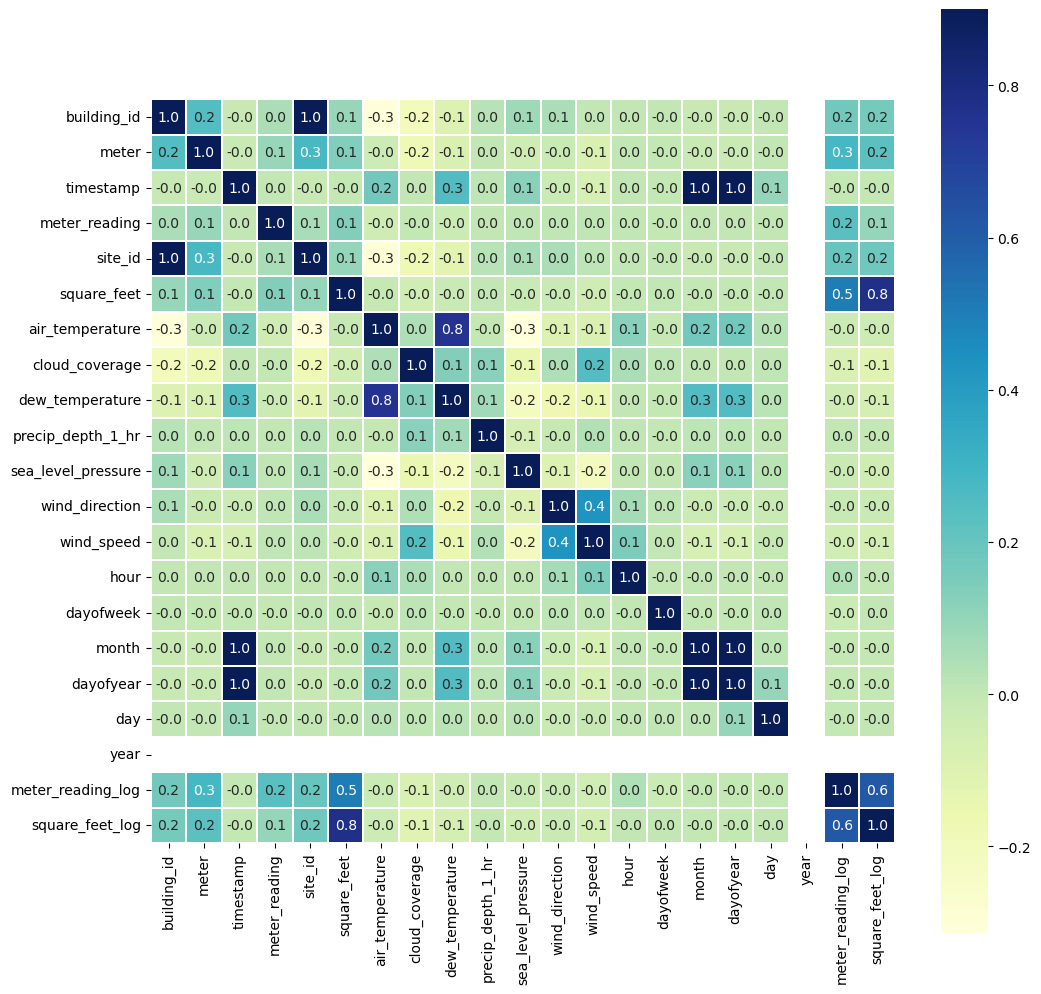

In [191]:
plt.figure(figsize=(12,12))
sns.heatmap(train_df.corr(), vmax=0.9, square=True, annot=True, linewidths=0.3, cmap="YlGnBu", fmt=".1f")

In [47]:
train_df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,wind_direction,wind_speed,hour,dayofweek,month,dayofyear,day,year,meter_reading_log,square_feet_log
0,0,0,2016-01-01,0.0,0,Education,7432,2008.0,NaN,25.0,...,0.0,0.0,0,4,1,1,1,2016,0.0,8.913685
1,1,0,2016-01-01,0.0,0,Education,2720,2004.0,NaN,25.0,...,0.0,0.0,0,4,1,1,1,2016,0.0,7.908755
2,2,0,2016-01-01,0.0,0,Education,5376,1991.0,NaN,25.0,...,0.0,0.0,0,4,1,1,1,2016,0.0,8.589886
3,3,0,2016-01-01,0.0,0,Education,23685,2002.0,NaN,25.0,...,0.0,0.0,0,4,1,1,1,2016,0.0,10.072639
4,4,0,2016-01-01,0.0,0,Education,116607,1975.0,NaN,25.0,...,0.0,0.0,0,4,1,1,1,2016,0.0,11.666573


In [49]:
train_df.dtypes

building_id                    int64
meter                          int64
timestamp             datetime64[ns]
meter_reading                float64
site_id                        int64
primary_use                   object
square_feet                    int64
year_built                   float64
floor_count                  float64
air_temperature              float64
cloud_coverage               float64
dew_temperature              float64
precip_depth_1_hr            float64
sea_level_pressure           float64
wind_direction               float64
wind_speed                   float64
hour                           uint8
dayofweek                      uint8
month                          uint8
dayofyear                     uint16
day                           uint16
year                          uint16
meter_reading_log            float64
square_feet_log              float64
dtype: object

In [ ]:
#train_df.drop(columns=['floor_count','year_built',], inplace=True)
train_df.hist(figsize=(20,15))

<Axes: >

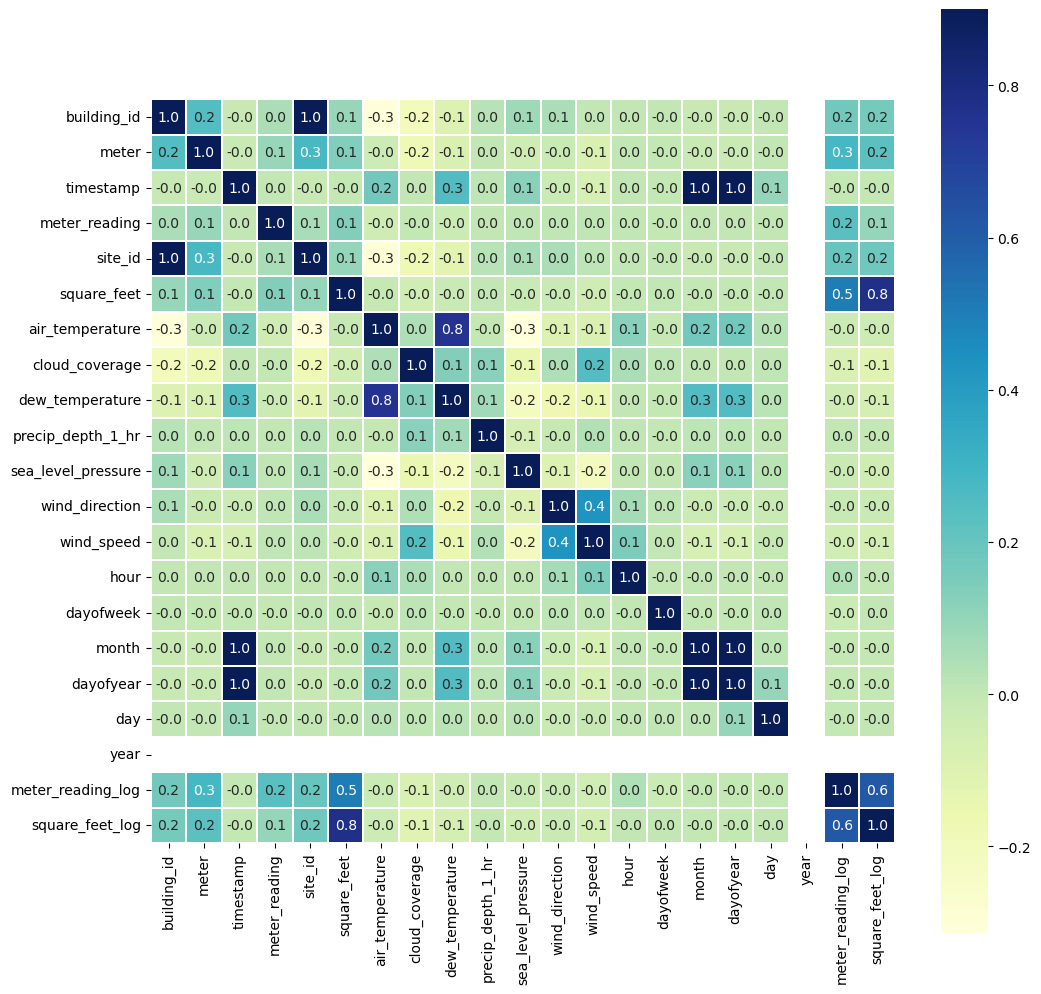

In [81]:
plt.figure(figsize=(12,12))
sns.heatmap(train_df.corr(), vmax=0.9, square=True, annot=True, linewidths=0.3, cmap="YlGnBu", fmt=".1f")

In [61]:
train_df['meter_reading'].value_counts()

meter_reading
0.0000       1867887
20.0000        23345
2.9307         23179
36.6000        22138
8.7921         21786
              ...   
5033.9200          1
545.5430           1
60.0011            1
31.3649            1
55.6241            1
Name: count, Length: 1736867, dtype: int64

In [63]:
train_df['meter_reading'].unique()

array([   0.        ,   15.60455607,   12.60368103, ..., 3006.82      ,
        852.77      ,   55.6241    ])

In [65]:
train_df.shape

(20125605, 23)

In [ ]:
train_df.drop(list(train_df[train_df['building_id']==1099].index), axis=0, inplace=True)

In [69]:
train_df.shape

(20108041, 23)

In [71]:
train_df.drop(list(train_df[train_df['meter_reading']==0.0].index), axis=0, inplace=True)

In [73]:
train_df.shape

(18240154, 23)

In [83]:
test_df = test_df.drop(['primary_use','floor_count','year_built'], axis=1)


In [85]:
train_df

,building_id,meter,timestamp,meter_reading,site_id,square_feet,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,...,wind_direction,wind_speed,hour,dayofweek,month,dayofyear,day,year,meter_reading_log,square_feet_log
45,46,0,2016-01-01 00:00:00,15.604556,0,9045,25.0,6.0,20.0,NaN,...,0.0,0.0,0,4,1,1,1,2016,2.809677,9.110078
72,74,0,2016-01-01 00:00:00,12.603681,0,387638,25.0,6.0,20.0,NaN,...,0.0,0.0,0,4,1,1,1,2016,2.610340,12.867830
91,93,0,2016-01-01 00:00:00,15.364478,0,33370,25.0,6.0,20.0,NaN,...,0.0,0.0,0,4,1,1,1,2016,2.795113,10.415443
103,105,0,2016-01-01 00:00:00,23.303600,1,50623,3.8,NaN,2.4,NaN,...,240.0,3.1,0,4,1,1,1,2016,3.190624,10.832181
104,106,0,2016-01-01 00:00:00,0.374600,1,5374,3.8,NaN,2.4,NaN,...,240.0,3.1,0,4,1,1,1,2016,0.318163,8.589514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20125599,1443,0,2016-12-31 23:00:00,64.950000,15,40311,1.7,NaN,-5.6,-1.0,...,180.0,8.8,23,5,12,366,31,2016,4.188897,10.604404
20125600,1444,0,2016-12-31 23:00:00,8.750000,15,19619,1.7,NaN,-5.6,-1.0,...,180.0,8.8,23,5,12,366,31,2016,2.277267,9.884305
20125601,1445,0,2016-12-31 23:00:00,4.825000,15,4298,1.7,NaN,-5.6,-1.0,...,180.0,8.8,23,5,12,366,31,2016,1.762159,8.366138
20125603,1447,0,2016-12-31 23:00:00,159.575000,15,29775,1.7,NaN,-5.6,-1.0,...,180.0,8.8,23,5,12,366,31,2016,5.078761,10.301458


In [89]:
middle_row = int(train_df.shape[0] / 2)

# Use iloc to split the DataFrame
train_df1 = train_df.iloc[:middle_row]  # First half
train_df2 = train_df.iloc[middle_row:]  # Second half


In [93]:
train_df1= train_df1.groupby(['meter',train_df1['building_id'],train_df1['month'], train_df1['day']]).agg({'meter_reading':'sum', 'air_temperature': 'mean', 'wind_speed': 'mean', 'precip_depth_1_hr': 'mean', 'cloud_coverage': 'mean', 'square_feet': 'mean'})

In [95]:
train_df2= train_df2.groupby(['meter',train_df2['building_id'],train_df2['month'], train_df2['day']]).agg({'meter_reading':'sum', 'air_temperature': 'mean', 'wind_speed': 'mean', 'precip_depth_1_hr': 'mean', 'cloud_coverage': 'mean', 'square_feet': 'mean'})

In [97]:
train_df2.head()

meter_reading  air_temperature  wind_speed  \
meter building_id month day                                               
0     0           7     8      1046.305742        33.250000    1.891667   
                        9      2099.412577        30.233333    2.666667   
                        10     2062.401960        28.650000    1.820833   
                        11     2128.621164        28.933333    1.995833   
                        12     2139.625017        29.170833    2.175000   

                             precip_depth_1_hr  cloud_coverage  square_feet  
meter building_id month day                                                  
0     0           7     8             0.000000        3.200000       7432.0  
                        9             0.000000        3.411765       7432.0  
                        10           -0.125000        3.538462       7432.0  
                        11            0.541667        3.500000       7432.0  
                        12            0.000000        4.428571       7432.0

In [111]:

train_df2['precip_depth_1_hr'].fillna(train_df2['precip_depth_1_hr'].mean(), inplace=True)
train_df2['wind_speed'].fillna(train_df2['wind_speed'].mean(), inplace=True)
train_df2['air_temperature'].fillna(train_df2['air_temperature'].mean(), inplace=True)
train_df2['cloud_coverage'].fillna(train_df2['cloud_coverage'].median(), inplace=True)
train_df2['square_feet'].fillna(train_df2['square_feet'].median(), inplace=True)

In [101]:
train_df1.dtypes

meter_reading        float64
air_temperature      float64
wind_speed           float64
precip_depth_1_hr    float64
cloud_coverage       float64
square_feet          float64
dtype: object

In [103]:
train_df1.isnull().sum()

meter_reading            0
air_temperature          3
wind_speed               3
precip_depth_1_hr    58363
cloud_coverage       30744
square_feet              0
dtype: int64

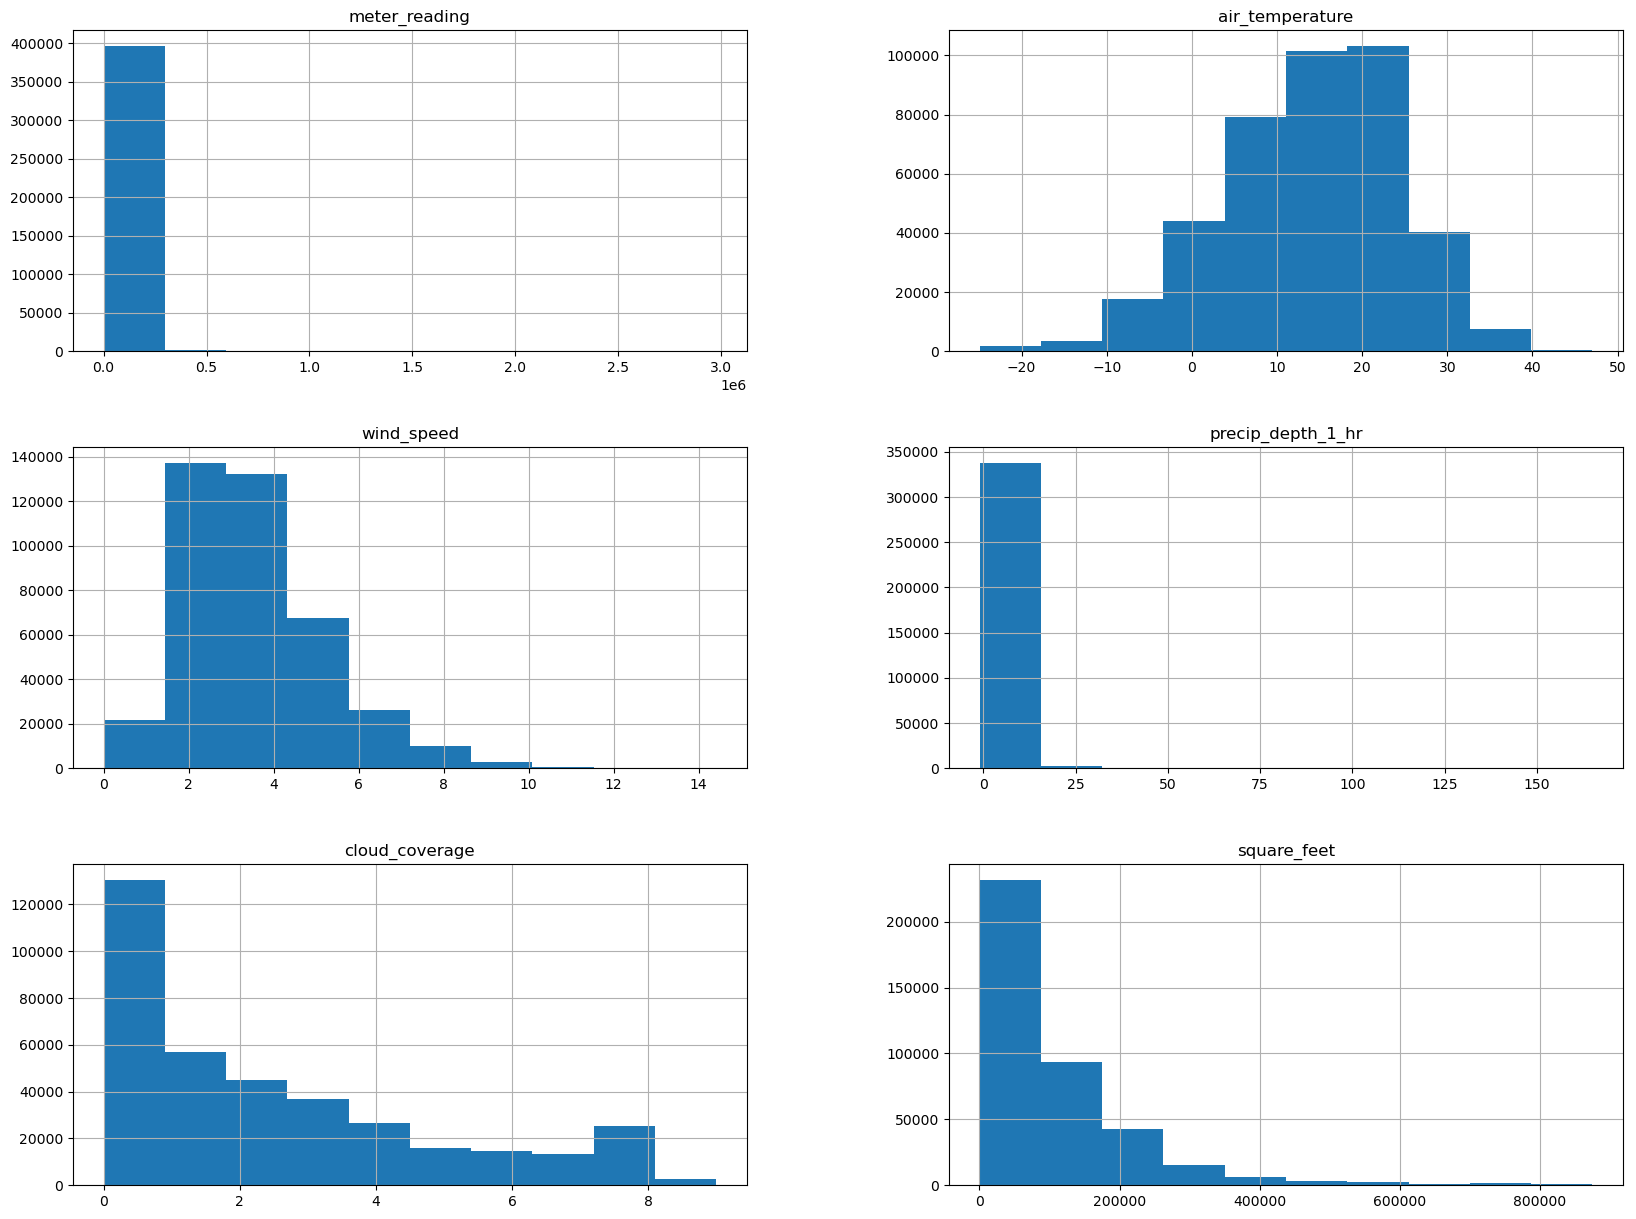

In [105]:
train_df1.hist(figsize=(20,15))
plt.show()

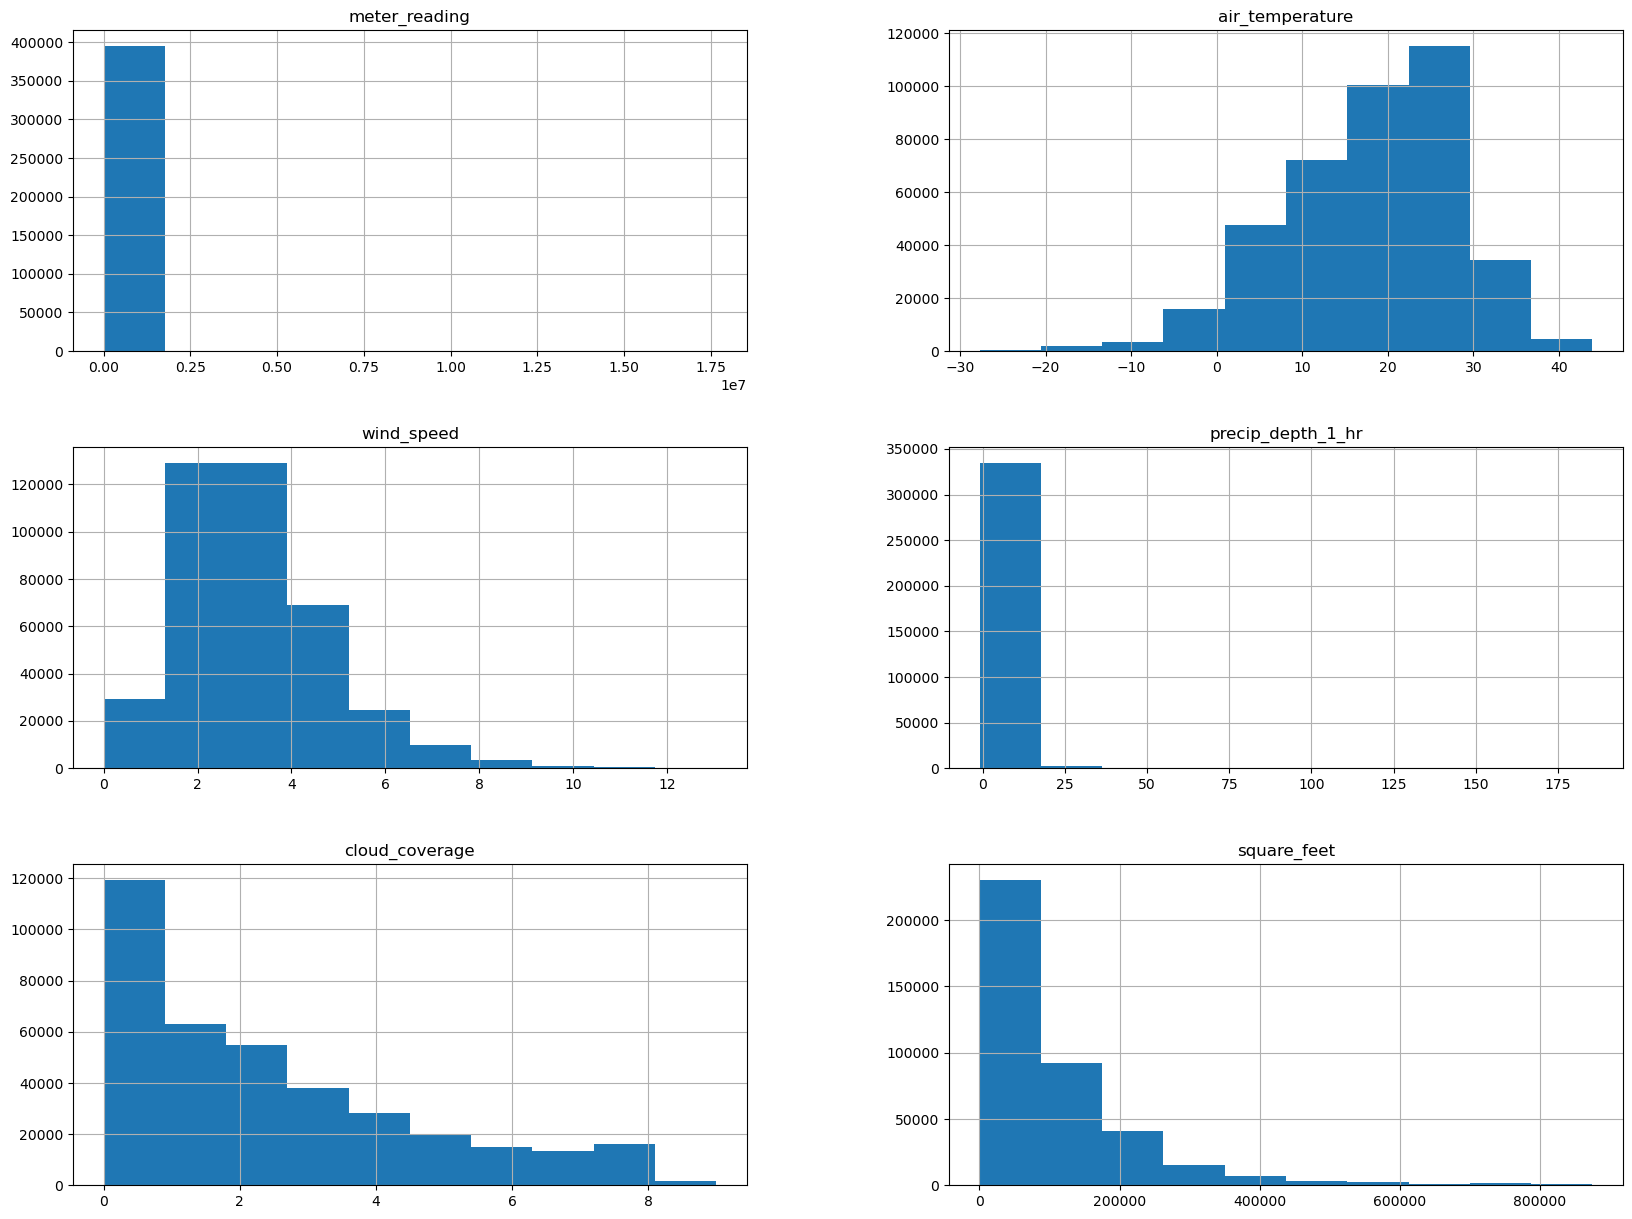

In [107]:
train_df2.hist(figsize=(20,15))
plt.show()

In [109]:

train_df1['wind_speed'].fillna(train_df1['wind_speed'].mean(), inplace=True)
train_df1['precip_depth_1_hr'].fillna(train_df1['precip_depth_1_hr'].mean(), inplace=True)
train_df1['air_temperature'].fillna(train_df1['air_temperature'].mean(), inplace=True)
train_df1['cloud_coverage'].fillna(train_df1['cloud_coverage'].median(), inplace=True)
train_df1['square_feet'].fillna(train_df1['square_feet'].median(), inplace=True)



In [113]:
train_df1.isnull().sum()

meter_reading        0
air_temperature      0
wind_speed           0
precip_depth_1_hr    0
cloud_coverage       0
square_feet          0
dtype: int64

In [121]:
test_df['cloud_coverage'].fillna(test_df['cloud_coverage'].median(), inplace=True)
test_df['precip_depth_1_hr'].fillna(test_df['precip_depth_1_hr'].median(), inplace=True)
test_df['sea_level_pressure'].fillna(test_df['sea_level_pressure'].median(), inplace=True)
test_df.isnull().sum()

row_id                      0
building_id                 0
meter                       0
timestamp                   0
site_id                     0
square_feet                 0
air_temperature         22872
cloud_coverage              0
dew_temperature         61770
precip_depth_1_hr           0
sea_level_pressure          0
wind_direction        2779634
wind_speed             103060
hour                        0
dayofweek                   0
month                       0
dayofyear                   0
day                         0
year                        0
dtype: int64

In [117]:
test_df.dtypes

row_id                         int64
building_id                    int64
meter                          int64
timestamp             datetime64[ns]
site_id                        int64
square_feet                    int64
air_temperature              float64
cloud_coverage               float64
dew_temperature              float64
precip_depth_1_hr            float64
sea_level_pressure           float64
wind_direction               float64
wind_speed                   float64
hour                           uint8
dayofweek                      uint8
month                          uint8
dayofyear                     uint16
day                           uint16
year                          uint16
dtype: object

In [123]:

test_df['wind_speed'].fillna(test_df['wind_speed'].mean(), inplace=True)
test_df['air_temperature'].fillna(test_df['air_temperature'].mean(), inplace=True)
test_df['square_feet'].fillna(test_df['square_feet'].median(), inplace=True)

In [125]:
test_df.isnull().sum()

row_id                      0
building_id                 0
meter                       0
timestamp                   0
site_id                     0
square_feet                 0
air_temperature             0
cloud_coverage              0
dew_temperature         61770
precip_depth_1_hr           0
sea_level_pressure          0
wind_direction        2779634
wind_speed                  0
hour                        0
dayofweek                   0
month                       0
dayofyear                   0
day                         0
year                        0
dtype: int64

In [139]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras import backend as K
from keras.losses import MeanSquaredError
from sklearn.model_selection  import train_test_split
from tensorflow.keras.utils import Sequence
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, LSTM, Embedding
from tensorflow.keras.optimizers import RMSprop,Adam
import keras.backend as K
import tensorflow as tf

In [129]:
pip install keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.3/277.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.4/670.4 kB 8.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 339.2/339.2 kB 4.9 MB/s eta 0:00:00:00:01
Note: you may need to restart the kernel to use updated packages.


In [135]:
from sklearn import preprocessing
from keras import backend as K
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization
from keras.models import Sequential
from keras.layers import SimpleRNN
from keras import regularizers
from tensorflow import keras

In [133]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.7/252.7 MB 5.4 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 8.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 9.0 MB/s eta 0:00:0000:0100:01m
Note: you may need to restart the kernel to use updated packages.


In [147]:
X1 = train_df[['meter', 'building_id', 'month', 'day','air_temperature', 'wind_speed', 'precip_depth_1_hr', 'cloud_coverage',
       'square_feet']]
y1 = train_df['meter_reading']

In [149]:
train_df.dtypes

building_id                    int64
meter                          int64
timestamp             datetime64[ns]
meter_reading                float64
site_id                        int64
square_feet                    int64
air_temperature              float64
cloud_coverage               float64
dew_temperature              float64
precip_depth_1_hr            float64
sea_level_pressure           float64
wind_direction               float64
wind_speed                   float64
hour                           uint8
dayofweek                      uint8
month                          uint8
dayofyear                     uint16
day                           uint16
year                          uint16
meter_reading_log            float64
square_feet_log              float64
dtype: object

In [151]:
x_train, x_test, y_train, y_test = train_test_split(X1,y1, test_size = 0.2, random_state= 45)

In [153]:
from sklearn.metrics import mean_squared_log_error

def root_mean_squared_error(y_true, y_pred):
  return K.sqrt(K.mean(K.square(y_pred - y_true)))

In [157]:
y1

45           15.604556
72           12.603681
91           15.364478
103          23.303600
104           0.374600
               ...    
20125599     64.950000
20125600      8.750000
20125601      4.825000
20125603    159.575000
20125604      2.850000
Name: meter_reading, Length: 18240154, dtype: float64

In [159]:
Early_stop = EarlyStopping(monitor='val_root_mean_squared_error', min_delta=0.0001, patience=5, verbose=True, mode='auto')

In [161]:
def model_gru(input_dim=10,metrics=root_mean_squared_error,loss='mse', optimizer="rmsprop",drop_rate=0.2):

  model = Sequential()
  model.add(GRU(128,return_sequences=True, input_shape=(None,input_dim)))
  model.add(Dropout(drop_rate))
  model.add(BatchNormalization())
  model.add(GRU(128,return_sequences=False))
  model.add(BatchNormalization())
  model.add(Dropout(drop_rate))
  model.add(Dense(1))
  model.compile(optimizer=optimizer, loss=loss, metrics=[metrics, 'accuracy'])
  
  return model

In [163]:
GRU_model = model_gru(input_dim=x_train.shape[-1],drop_rate=0.2)


In [165]:
GRU_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, None, 128)      │        53,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, None, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,601 (600.00 KB)

 Trainable params: 153,089 (598.00 KB)

 Non-trainable params: 512 (2.00 KB)

In [173]:
hist = transform(GRU_model,x_train,y_train,epochs=30,batch_size=500,verbose=1,validation_data=(x_val1,y_val1), callbacks =[Early_stop])

NameError: name 'transform' is not defined

In [169]:
from sklearn.preprocessing import StandardScaler


In [179]:
loss, metric = GRU_model.evaluate(x_test, y_test)

print(f"Test Loss: {loss}")
print(f"Test Metric: {metric}")


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(None, 9), dtype=float32). Expected shape (None, None, 9), but input has incompatible shape (None, 9)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 9), dtype=float32)
  • training=False
  • mask=None

In [189]:
from sklearn.tree import DecisionTreeClassifier

test_accuracy=[]
n_estimator = range(80,150,10)

for n in n_estimator:
  tree_clf = Pipeline(
      [('preprocessing',preprocessor),
       ('classifier', DecisionTreeClassifier(max_depth=n, random_state=10))
       ]   
  )
  tree_clf.fit(x_train, y_train)
  y_hat = tree_clf.predict(x_val)
  test_accuracy.append(accuracy_score(y_val,y_hat))
index_n = test_accuracy.index(max(test_accuracy))
optimum_n = n_estimator[index_n]
optimum_n
#max_depth = 14 random_state = 10 optimal is 110 but this is not reasonable within the software limitations

NameError: name 'preprocessor' is not defined

In [187]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier